# K-Means-segmentering af abonnentadfærd med PROC FASTCLUS

## Resumé

Denne notebook segmenterer en syntetisk base på 100 mobilabonnenter i adfærdsklynger ved hjælp af `PROC FASTCLUS`, Base SAS' k-means-klyngeprocedure. Syv forbrugsfunktioner standardiseres til z-scorer med `PROC STDIZE`, så variable med høj størrelsesorden (taleminutter, SMS-antal) ikke dominerer den euklidiske afstand, hvorefter `PROC FASTCLUS` tilpasser tre klynger. Proceduren rapporterer den gennemsnitlige kvadratiske afvigelse inden for hver klynge (RMS), en samlet R-i-anden og pseudo-F, der kvantificerer, hvor godt segmenteringen adskiller basen (her en samlet R-i-anden på 0,575 og pseudo-F på 65,75), og skriver en scoret tabel med et `CLUSTER`-mærkat på hver abonnent. Vi sammenfletter disse mærkater tilbage på data i original skala, profilerer personaerne og overdrager tildelingerne til downstream-aktivering.

## Datakilder

| Datasæt | Beskrivelse | Rækker | Nøglevariable |
| ------- | ----------- | ---: | ------------- |
| `subscribers` | Syntetisk månedligt adfærds-øjebliksbillede for en mobiltelefon-abonnentbase, genereret direkte med `call streaminit` / `rand()`. Tre latente adfærdstyper (stort dataforbrug, talecentreret, lavt forbrug) blandes med støj. | 100 | `subscriber_id`, `tenure_months`, `monthly_data_gb`, `voice_minutes`, `sms_count`, `arpu`, `intl_minutes`, `support_calls`, `data_plan` (nominel), `region` (nominel) |

# K-Means-segmentering af abonnentadfærd

**Branche:** Telekommunikation &nbsp;|&nbsp; **Procedure:** `PROC FASTCLUS` (Base SAS k-means-klyngedannelse)

Mobiloperatører har abonnenter, hvis månedlige adfærd -- dataappetit, talevaner, forbrug og supportfriktion -- falder i et lille antal genkendelige mønstre. At opdage disse mønstre gør det muligt for virksomheden at målrette fastholdelsestiltag, opsælge de rigtige pakker og erhverve lignende kunder. Denne notebook opbygger en adfærdssegmentering fra ende til anden: genererer et realistisk abonnent-øjebliksbillede, standardiserer funktionerne, lader `PROC FASTCLUS` tilpasse klyngerne, scorer hver abonnent og profilerer segmenterne i brugbare personaer. `PROC FASTCLUS` er designet netop til denne disjunkte k-means-opgave og skalerer til meget store baser ved at gennemløbe data i stedet for at opbygge en fuld afstandsmatrix.

## 1. Generer en syntetisk abonnentbase

Vi simulerer 100 abonnenter trukket fra tre latente adfærdsarketyper -- **streamere med stort dataforbrug**, **talecentrerede traditionalister** og **kunder med let/lavt forbrug** -- og blander derefter støj i, så grænserne er uskarpe (som de er i virkeligheden). Hver abonnent har også to kategoriske attributter, `data_plan` og `region`, som vi senere bruger til at *profilere* segmenterne. Seedet gør data reproducerbare.

In [1]:
/* -----------------------------------------------------------
   Synthetic mobile subscriber snapshot (100 rows).
   Three latent behavior archetypes + noise, plus two
   categorical attributes for segment profiling.
   Category-string assignment uses a direct IF/ELSE chain
   (not a fixed-width array literal) to avoid a known
   truncation bug with non-ASCII array-literal initializers.
   ----------------------------------------------------------- */
data subscribers;
    CALL streaminit(20260531);

    LÆNGDE data_plan $16 region $10;

    GØR subscriber_id = 100001 TIL 100100;

        /* latent archetype: 1=heavy data, 2=voice, 3=low usage */
        u = rand('uniform');
        HVIS      u < 0.38 SÅ archetype = 1;
        ELLERS HVIS u < 0.70 SÅ archetype = 2;
        ELLERS                  archetype = 3;

        tenure_months = MAX(1, round(rand('gamma', 2.2) * 12));

        HVIS archetype = 1 SÅ GØR;             /* heavy-data streamer */
            monthly_data_gb = MAX(0.5, rand('normal', 42, 11));
            voice_minutes   = MAX(0,   rand('normal', 180, 70));
            sms_count       = MAX(0,   round(rand('normal', 60, 30)));
            intl_minutes    = MAX(0,   rand('normal', 22, 14));
            arpu            = MAX(15,  rand('normal', 78, 14));
            support_calls   = rand('poisson', 0.8);
            planpick = ifn(rand('uniform') < 0.65, 3, 2);
        SLUT;
        ELLERS HVIS archetype = 2 SÅ GØR;        /* voice-centric */
            monthly_data_gb = MAX(0.2, rand('normal', 9, 4));
            voice_minutes   = MAX(0,   rand('normal', 620, 160));
            sms_count       = MAX(0,   round(rand('normal', 210, 80)));
            intl_minutes    = MAX(0,   rand('normal', 95, 45));
            arpu            = MAX(12,  rand('normal', 55, 12));
            support_calls   = rand('poisson', 1.6);
            planpick = ifn(rand('uniform') < 0.55, 2, 1);
        SLUT;
        ELLERS GØR;                              /* low usage */
            monthly_data_gb = MAX(0.1, rand('normal', 3, 1.5));
            voice_minutes   = MAX(0,   rand('normal', 110, 50));
            sms_count       = MAX(0,   round(rand('normal', 35, 20)));
            intl_minutes    = MAX(0,   rand('normal', 6, 6));
            arpu            = MAX(8,   rand('normal', 26, 7));
            support_calls   = rand('poisson', 0.5);
            planpick = ifn(rand('uniform') < 0.70, 1, 2);
        SLUT;

        HVIS planpick = 1 SÅ data_plan = 'Forudbetalt';
        ELLERS HVIS planpick = 2 SÅ data_plan = 'EfterbetaltM';
        ELLERS data_plan = 'Ubegrænset';

        regionpick = rand('table', 0.30, 0.28, 0.22, 0.20);
        HVIS regionpick = 1 SÅ region = 'Nord';
        ELLERS HVIS regionpick = 2 SÅ region = 'Syd';
        ELLERS HVIS regionpick = 3 SÅ region = 'Øst';
        ELLERS region = 'Vest';

        /* round to tidy reporting precision */
        monthly_data_gb = round(monthly_data_gb, 0.1);
        voice_minutes   = round(voice_minutes,   1);
        intl_minutes    = round(intl_minutes,    1);
        arpu            = round(arpu,            0.01);

        UDDATA;
    SLUT;

    BEHOLD subscriber_id tenure_months monthly_data_gb voice_minutes
         sms_count intl_minutes arpu support_calls data_plan region;
KØR;


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## 2. Undersøg fordelingen af funktionerne

Inden klyngedannelsen ser vi på skala og spredning for hver adfærdsfunktion. De vidt forskellige enheder -- gigabyte, minutter, dollar, antal -- er netop grunden til, at vi standardiserer intervalinputtene inden klyngedannelsen; ellers ville variable med høj størrelsesorden som `voice_minutes` dominere den euklidiske afstand, som `PROC FASTCLUS` minimerer.

                                                  The MEANS Procedure

 Variable         Label                               N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------------------------------------------
 tenure_months    Anciennitet (måneder)             100        27.6        18.9         3.0             13.0        22.0             37.5        98.0
 monthly_data_gb  Månedligt dataforbrug (GB)        100        18.2        18.9         0.1              3.7         9.6             31.5        67.2
 voice_minutes    Taleminutter                      100       304.2       236.6         0.0            125.0       217.0            527.5       912.0
 sms_count        Antal SMS                         100       102.0       102.6         0.0             35.0        64.0            130.0       404.0
 intl_minutes     Internation


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_data_plan.spec.json
NOTE: ODS plot written: freq_region.spec.json
NOTE: PROC FREQ statement used.


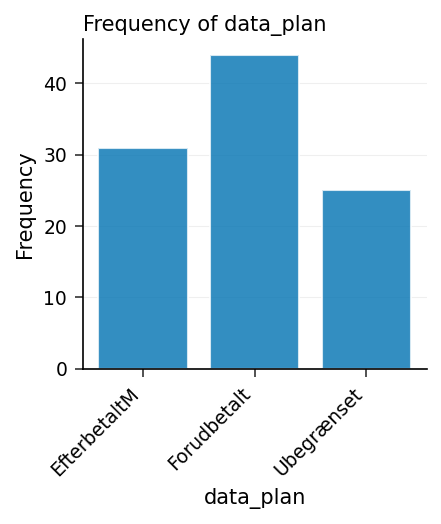

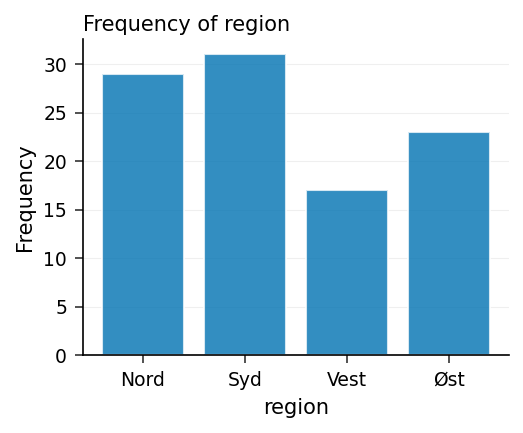

In [2]:
/* Summary statistics for the clustering inputs */
PROCEDURE GENNEMSNIT data=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
    MÆRKAT tenure_months='Anciennitet (måneder)' monthly_data_gb='Månedligt dataforbrug (GB)'
          voice_minutes='Taleminutter' sms_count='Antal SMS'
          intl_minutes='Internationale minutter' arpu='ARPU ($)'
          support_calls='Supportopkald';
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
KØR;

/* Frequency of the two categorical inputs */
PROCEDURE FREKVENSER data=subscribers;
    MÆRKAT data_plan='Dataplan' region='Region';
    TABLES data_plan region / nocum;
KØR;

## 3. Standardisér funktionerne til z-scorer

`PROC FASTCLUS` minimerer euklidisk afstand, så en variabel målt i hundredvis af minutter ville overdøve en, der måles i encifrede gigabyte. `PROC STDIZE` med `METHOD=STD` omskalerer hver intervalfunktion til middelværdi 0 og standardafvigelse 1, hvilket giver hver adfærd lige vægt i afstanden. De kategoriske kolonner og identifikatoren går uændret igennem, så vi bagefter kan profilere klyngerne i deres oprindelige skala.

In [3]:
/* z-score the interval features; ids and categoricals pass through */
PROCEDURE stdize data=subscribers out=subs_std METHOD=std;
    MÆRKAT tenure_months='Anciennitet (måneder)' monthly_data_gb='Månedligt dataforbrug (GB)'
          voice_minutes='Taleminutter' sms_count='Antal SMS'
          intl_minutes='Internationale minutter' arpu='ARPU ($)'
          support_calls='Supportopkald';
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
KØR;


NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std


## 4. Tilpas k-means-segmenteringen

Vi tilpasser tre segmenter med `PROC FASTCLUS`. `MAXCLUSTERS=3` sætter *k*; `MAXITER=20` lader klyngecentrene iterere til konvergens. Proceduren rapporterer et **klyngeresumé** (størrelse og RMS-afvigelse inden for hver klynge), **statistik for variable** (den R-i-anden, hver funktion bidrager med), en **samlet R-i-anden** og **pseudo-F**, der måler, hvor rent de tre klynger adskiller basen, samt **klyngegennemsnit** på den standardiserede skala. `OUT=scored` skriver inputrækkerne tilbage med et `CLUSTER`-mærkat og `DISTANCE` fra hver abonnent til dens klyngefrø.

In [4]:
/* k-means fit on the standardized features: 3 segments. */
PROCEDURE FASTCLUS data=subs_std maxclusters=3 MAXITER=20 out=scored;
    MÆRKAT tenure_months='Anciennitet (måneder)' monthly_data_gb='Månedligt dataforbrug (GB)'
          voice_minutes='Taleminutter' sms_count='Antal SMS'
          intl_minutes='Internationale minutter' arpu='ARPU ($)'
          support_calls='Supportopkald';
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
KØR;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=20                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  36         0.5293             2.6279              3         3.0809
2                  34         0.7925             3.4184              3         3.5916
3                  30         0.6295             3.9300              1         3.0809

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 7 variables, 3 clusters using k-means


## 5. Knyt segmentmærkater til data i original skala

Den scorede tabel indeholder de standardiserede funktioner; til profilering ønsker vi klyngerne beskrevet i reelle gigabyte, minutter og dollar. Vi sammenfletter `CLUSTER`-mærkatet tilbage på den oprindelige `subscribers`-tabel via `subscriber_id` og stiller derefter det første spørgsmål, marketing altid stiller: *hvor stort er hvert segment?*

                                                   The FREQ Procedure

Klynge    Frequency    Percent
-------------------------------
1                36     36.00
2                34     34.00
3                30     30.00



NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote clus_assign (100 rows, 12 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 10 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


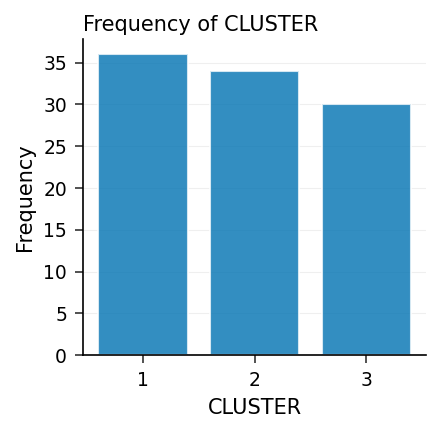

In [5]:
/* carry the cluster label back to the original-scale data */
PROCEDURE SORTER data=scored(keep=subscriber_id cluster distance) out=clus_assign;
    EFTER subscriber_id;
KØR;
PROCEDURE SORTER data=subscribers out=subs_sorted;
    EFTER subscriber_id;
KØR;
data profile;
    SAMMENFLET subs_sorted clus_assign;
    EFTER subscriber_id;
KØR;

/* How many subscribers landed in each segment? */
PROCEDURE FREKVENSER data=profile;
    MÆRKAT CLUSTER='Klynge';
    TABLES CLUSTER / nocum;
KØR;

## 6. Profilér segmenterne

Klynge-id'er er meningsløse, indtil vi beskriver *adfærden* i hver af dem. At gennemsnitsberegne de oprindelige (ikke-standardiserede) funktioner efter `CLUSTER` afslører personaen bag hvert segment -- hvem streamer, hvem taler, hvem bruger næsten ikke netværket -- og den kategoriske sammensætning viser, hvilke planer og regioner der koncentreres i hvert.

                                                  The MEANS Procedure

                                Analysis Variable : tenure_months Anciennitet (måneder)

        Klynge            N Obs           Mean
        --------------------------------------
        1                    36           28.9
        2                    34           25.8
        3                    30           28.1
        --------------------------------------

                            Analysis Variable : monthly_data_gb Månedligt dataforbrug (GB)

        Klynge            N Obs           Mean
        --------------------------------------
        1                    36            4.0
        2                    34           10.2
        3                    30           44.4
        --------------------------------------

                                     Analysis Variable : voice_minutes Taleminutter

        Klynge            N Obs           Mean
        --------------------------------------
   


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_data_plan.spec.json
NOTE: ODS plot written: freq_mosaic_cluster_region.spec.json
NOTE: PROC FREQ statement used.


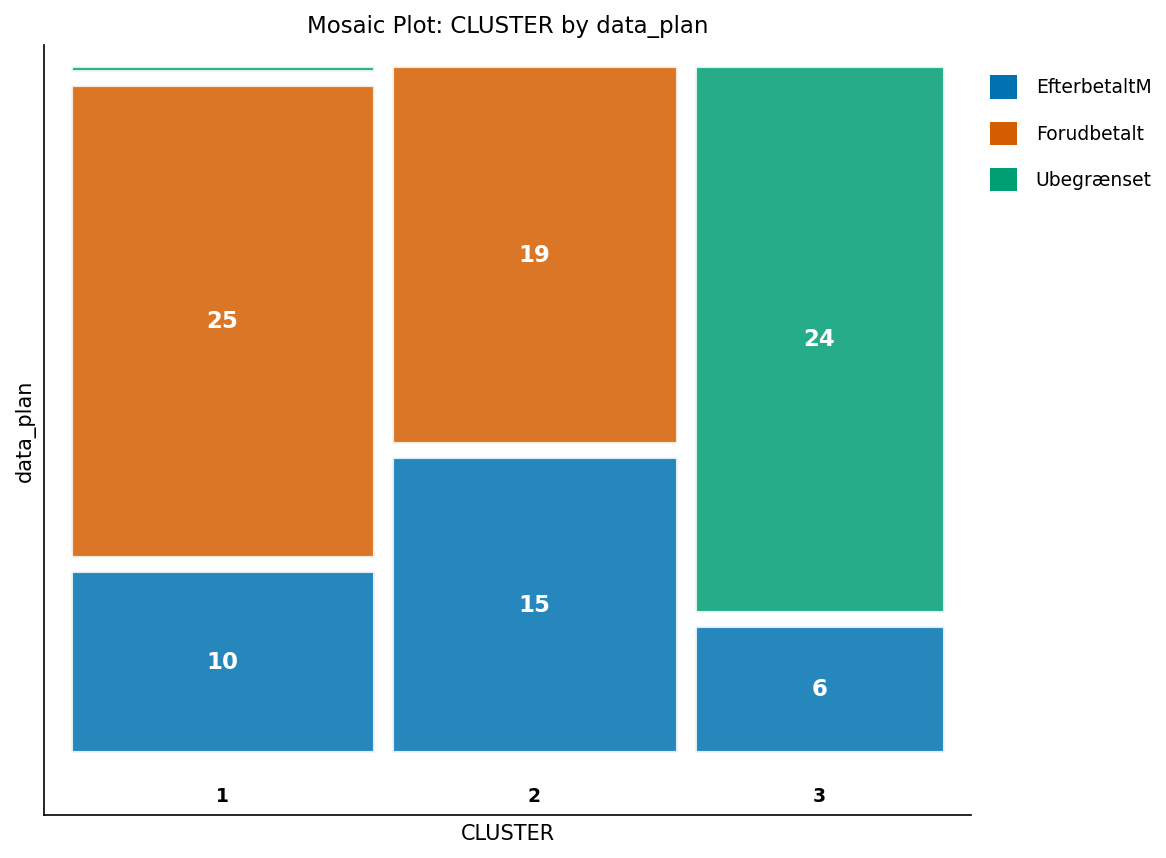

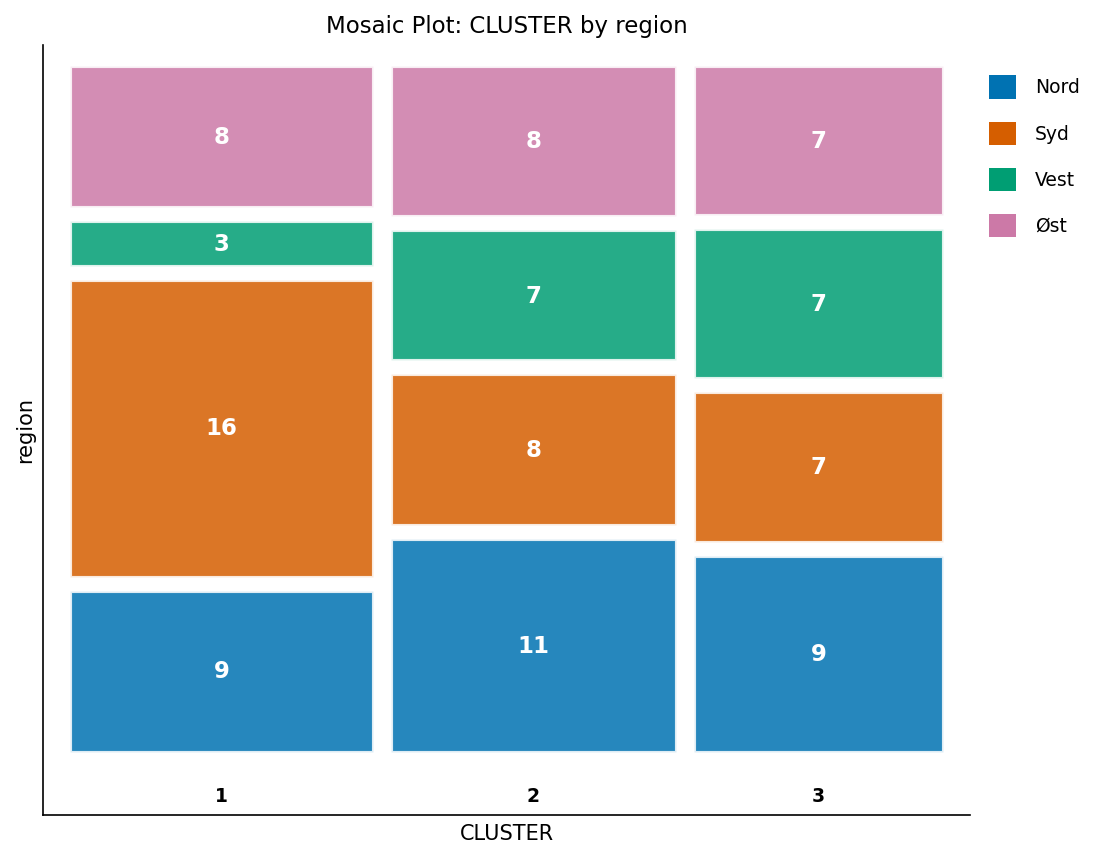

In [6]:
/* Behavioral profile: mean of each feature by segment */
PROCEDURE GENNEMSNIT data=profile n mean maxdec=1;
    KLASSE CLUSTER;
    MÆRKAT CLUSTER='Klynge' tenure_months='Anciennitet (måneder)' monthly_data_gb='Månedligt dataforbrug (GB)'
          voice_minutes='Taleminutter' sms_count='Antal SMS'
          intl_minutes='Internationale minutter' arpu='ARPU ($)'
          support_calls='Supportopkald';
    VARIABEL tenure_months monthly_data_gb voice_minutes sms_count
        intl_minutes arpu support_calls;
KØR;

/* Categorical mix within each segment */
PROCEDURE FREKVENSER data=profile;
    MÆRKAT CLUSTER='Klynge' data_plan='Dataplan' region='Region';
    TABLES CLUSTER * data_plan / norow nopercent;
    TABLES CLUSTER * region    / norow nopercent;
KØR;

## 7. Visualisér segmenterne

Et billede gør segmenteringen konkret. Vi plotter dataappetit mod taleforbrug, farvet efter segment, og tilføjer et boxplot af ARPU pr. segment, så indtægtshistorien er tydelig ved et blik.


NOTE: ODS Graphics is ON (width=720px, height=520px, format=SVG).
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=profile

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


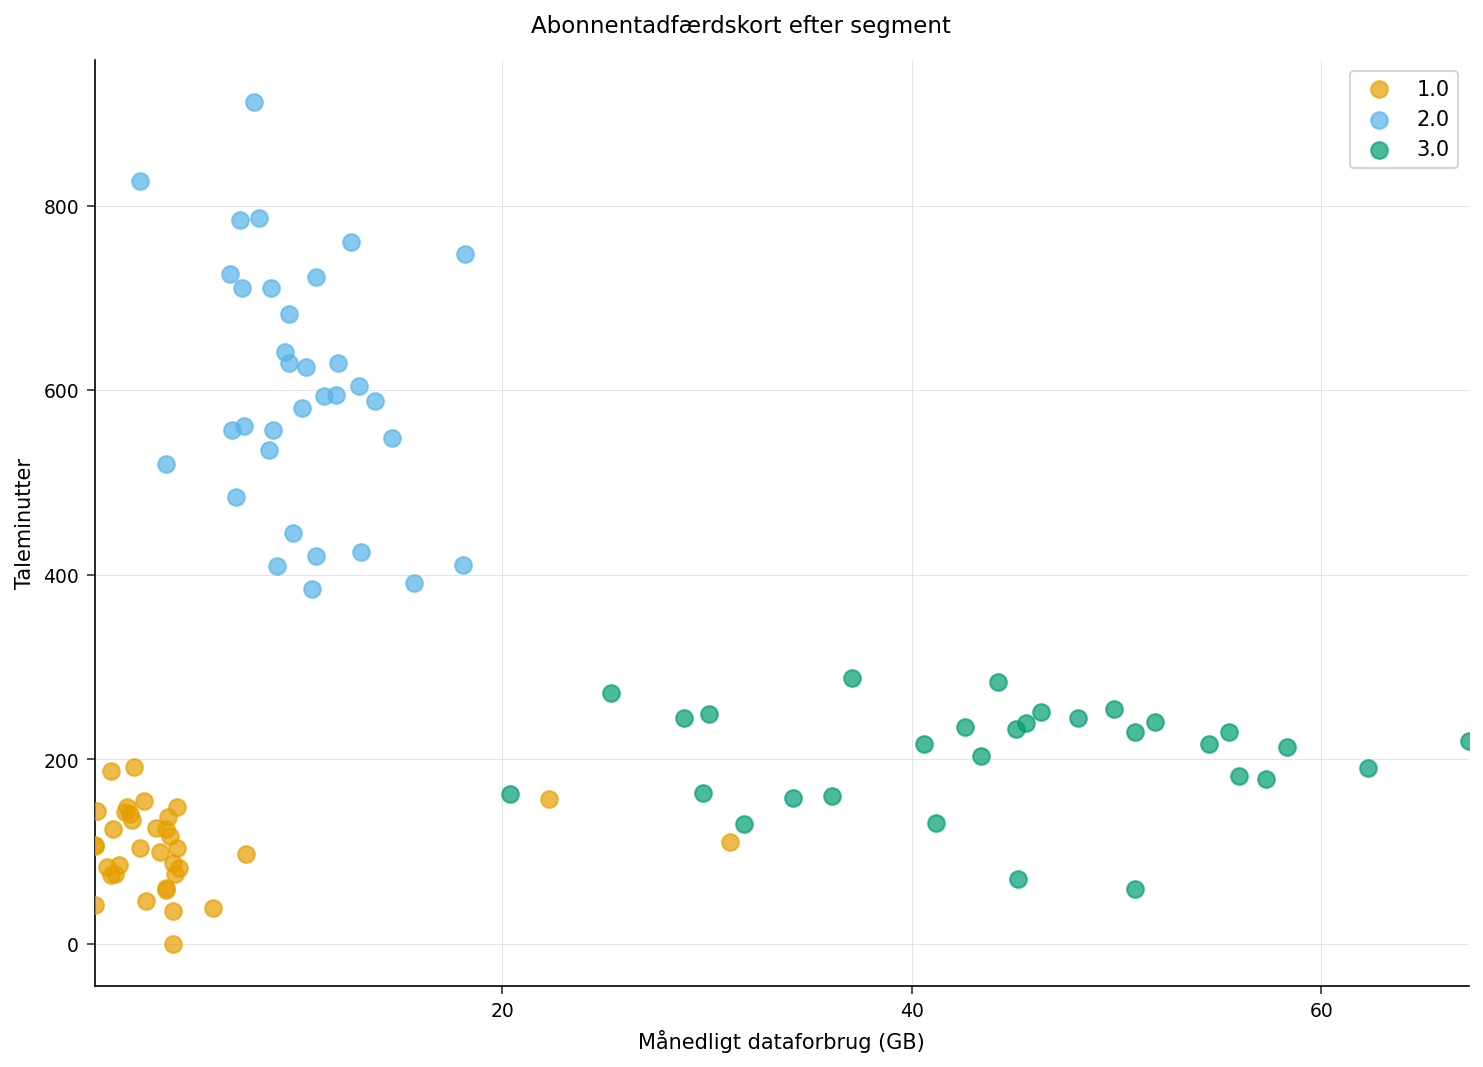

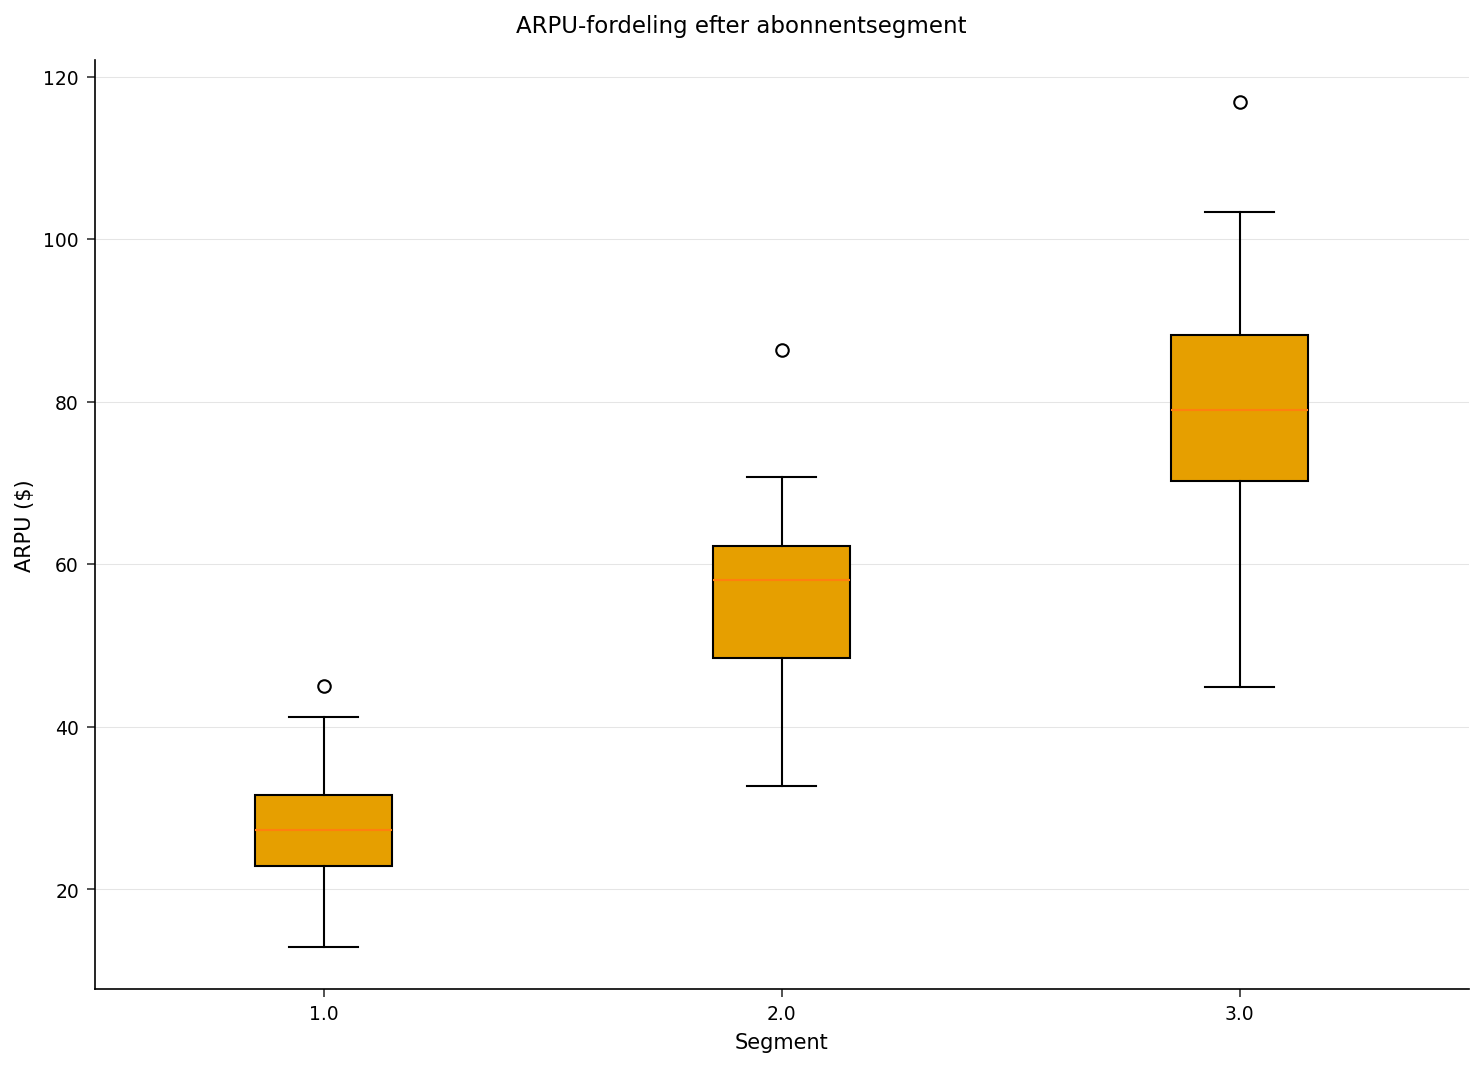

In [7]:
ODS GRAPHICS ON / imagefmt=svg WIDTH=720 HEIGHT=520;

/* Behavioral map: data vs. voice, colored by segment */
PROCEDURE SGPLOT data=profile;
    SCATTER x=monthly_data_gb y=voice_minutes
            / GROUP=CLUSTER
              MARKERATTRS=(size=8 SYMBOL=circlefilled)
              TRANSPARENCY=0.3;
    XAXIS label='Månedligt dataforbrug (GB)' grid;
    YAXIS label='Taleminutter'     grid;
    TITEL 'Abonnentadfærdskort efter segment';
KØR;

/* Revenue distribution per segment */
PROCEDURE SGPLOT data=profile;
    VBOX arpu / category=CLUSTER;
    XAXIS label='Segment';
    YAXIS label='ARPU ($)' grid;
    TITEL 'ARPU-fordeling efter abonnentsegment';
KØR;

## 8. Eksportér de scorede segmenter

Til sidst overdrager vi tildelingerne til downstream CRM- og kampagnesystemer. Vi beholder identifikatoren, klyngemærkatet og de vigtigste adfærdsfelter.

In [8]:
/* Persist the segment assignments for activation */
data subscriber_segments;
    SÆT profile;
    BEHOLD subscriber_id CLUSTER tenure_months
         monthly_data_gb voice_minutes arpu data_plan region;
KØR;

PROCEDURE UDSKRIV data=subscriber_segments(obs=10) noobs MÆRKAT;
    MÆRKAT subscriber_id='Abonnent-id' CLUSTER='Klynge' tenure_months='Anciennitet (måneder)'
          monthly_data_gb='Månedligt dataforbrug (GB)' voice_minutes='Taleminutter'
          arpu='ARPU ($)' data_plan='Dataplan' region='Region';
    TITEL 'Udsnit af scorede abonnentsegmenter';
KØR;

                                          Udsnit af scorede abonnentsegmenter                                           

Abonnent-id  Klynge   Anciennitet (måneder)   Månedligt dataforbrug (GB)  Taleminutter  ARPU ($)      Dataplan  Region
     100001       1                      30                          2.3           104        28  Forudbetalt   Syd
     100002       2                       8                         10.2           581     57.78  Forudbetalt   Vest
     100003       2                       8                         10.7           385     55.66  EfterbetaltM  Nord
     100004       2                      68                          7.4           561     70.68  Forudbetalt   Nord
     100005       3                      18                         45.6           239     63.85  Ubegrænset    Nord
     100006       3                      10                         30.1           249     88.33  Ubegrænset    Øst
     100007       1                      62                


NOTE: DATA subscriber_segments


NOTE: Read 100 rows from profile.
NOTE: Wrote subscriber_segments (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC PRINT data=subscriber_segments

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Fortolkning af resultaterne

`PROC FASTCLUS` fandt tre rene, veladskilte segmenter. Tilpasningen er solid: den **samlede R-i-anden er 0,575**, og **pseudo-F er 65,75**, hvilket betyder, at de tre klynger forklarer omkring 58% af den samlede variation i de standardiserede funktioner. Adskillelsen drives næsten udelukkende af de adfærdssignaler, vi interesserer os for -- `voice_minutes` (R-i-anden 0,858), `monthly_data_gb` (0,844) og `arpu` (0,771) bærer segmenteringen, mens `tenure_months` (0,000) og `support_calls` (0,193) bidrager med næsten intet, hvilket bekræfter, at *hvordan* en abonnent bruger netværket -- ikke hvor længe vedkommende har været kunde -- definerer personaerne.

De tre segmenter kortlægges direkte til marketingklare personaer, her profileret i original (ikke-standardiseret) skala:

| Segment | n (andel) | Karakteristisk adfærd | Planfordeling | Persona | Anbefalet tiltag |
| :-----: | :-------: | ------------------ | -------- | ------- | ---------------- |
| **3** | 30 (30%) | Højeste dataforbrug: **44,4 GB/md.**, højeste forbrug **$79,1 ARPU**, moderat tale (205 min) | 24/30 **Ubegrænset** | **Streamere med stort dataforbrug** | Beskyt og opsælg: hurtigere niveauer, indholdspakker, enhedsopgraderinger |
| **2** | 34 (34%) | Højeste tale **603 min/md.**, **214 SMS**, **106 int. min**, mellemforbrug **$55,9 ARPU** | Forudbetalt + EfterbetaltM, **ingen Ubegrænset** | **Talecentrerede traditionalister** | Internationale tillægsydelser, familie-/talepakker, loyalitetsfordele |
| **1** | 36 (36%) | Laveste forbrug: **4,0 GB**, 104 taleminutter, laveste forbrug **$28,0 ARPU** | 25/36 **Forudbetalt** | **Let/lavt forbrug** | Tilpas planstørrelse, autobetalings-nudges, billige dataopstartspakker for at øge forbruget |

Planfordelingen bekræfter adfærdslæsningen: segmentet med stort dataforbrug ligger overvejende på **Ubegrænset**-planer (24 af 30), det talecentrerede segment har **ingen** Ubegrænset-abonnenter, og segmentet med lavt forbrug er hovedsageligt **Forudbetalt** (25 af 36). Region er derimod jævnt fordelt på tværs af alle tre segmenter -- geografi er ikke en adfærdsdriver her, hvilket i sig selv er et nyttigt fund til kampagnemålretning.

**Hvorfor `PROC FASTCLUS` passer til dette problem.** Den kører disjunkt k-means ved at gennemløbe data i stedet for at materialisere en fuld afstandsmatrix, så det samme program, der segmenterede disse 100 abonnenter, skalerer til meget store baser. Standardisering med `PROC STDIZE` først fjernede skævheden i enhedsskala på tværs af gigabyte, minutter og dollar, så hver adfærd bidrog lige meget til den euklidiske afstand; R-i-anden-diagnostikken fortalte os derefter, *hvilke* funktioner der reelt drev opdelingen. Det scorede output -- et `CLUSTER`-mærkat på hver abonnent -- går direkte ind i aktiveringspipelines og lukker sløjfen fra rå adfærd til målrettet tilbud.

---

<div style="font-size:11px;color:#9e9e9e">Denne notebook er udelukkende til demonstrationsformål. Data er syntetiske, og resultaterne udgør ikke forretningsrådgivning.</div>